# Bitcoin Causal Effect Example — DML vs DR Comparison

This notebook compares two causal inference models, `LinearDML` and `DRLearner`, from the `econml` library to estimate the effect of Google Trends interest in "Bitcoin" on actual Bitcoin returns.


In [1]:
from bitcoin_utils import (
    prepare_dataset,
    train_dml_model,
    train_cf_model,  
    plot_effects
)



In [2]:
df = prepare_dataset()
df.head()


,date,price,trend,price_change,trend_scaled
0,2025-02-17,96149.348455,42,0.000000,-0.530453
1,2025-02-18,95776.157239,49,-0.003881,-0.051677
2,2025-02-19,95495.891533,44,-0.002926,-0.393660
3,2025-02-20,96554.871563,46,0.011089,-0.256867
4,2025-02-21,98384.317382,49,0.018947,-0.051677


Model LassoCV(cv=5) has a non-default cv attribute, which will be ignored


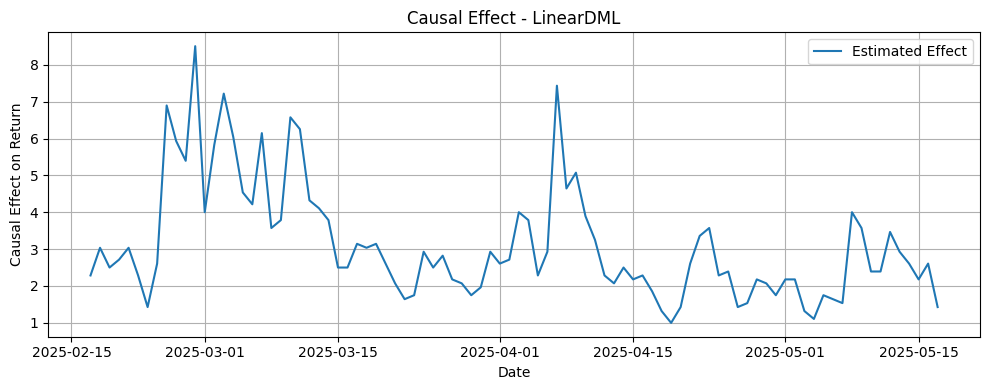

In [3]:
effect_dml, model_dml = train_dml_model(df)

plot_effects(df, effect_dml, title="Causal Effect - LinearDML")


Model LassoCV(cv=5) has a non-default cv attribute, which will be ignored


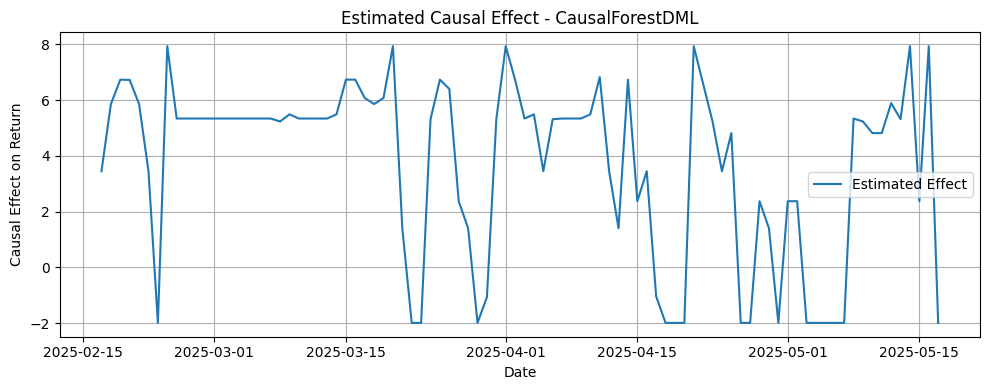

In [5]:
effect_cf, model_cf = train_cf_model(df)
plot_effects(df, effect_cf, title="Estimated Causal Effect - CausalForestDML")




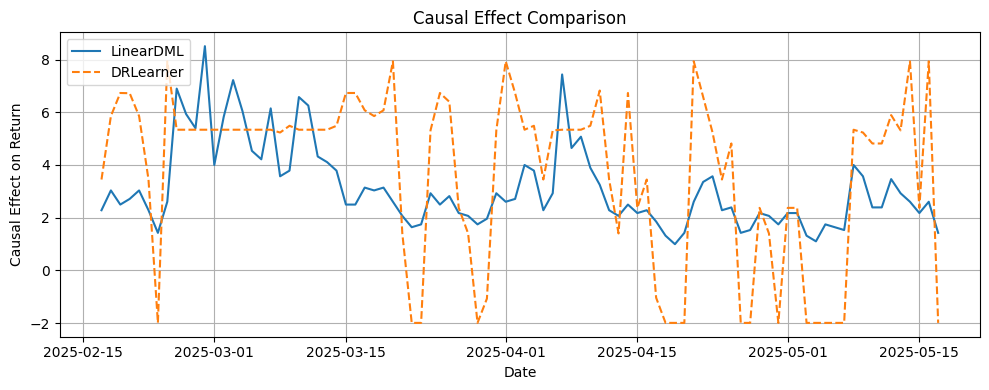

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(df["date"], effect_dml, label="LinearDML")
plt.plot(df["date"], effect_cf, label="DRLearner", linestyle="--")
plt.title("Causal Effect Comparison")
plt.xlabel("Date")
plt.ylabel("Causal Effect on Return")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Causal Effect Comparison: LinearDML vs DRLearner
The plot above compares the estimated causal effect of Google Trends interest on Bitcoin returns using two methods:

LinearDML (blue line): Captures a smoother, more stable causal trend, assuming a linear relationship.
DRLearner (orange dashed line): Reveals higher volatility and non-linear variations in estimated effects.
While both models show similar directional trends, DRLearner identifies sharper shifts in causal influence potentially highlighting regime changes or outliers that LinearDML smooths over.

This comparison highlights the benefit of using both models to assess causal effects under different modeling assumptions.